In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

from scipy.interpolate import interp1d,CubicSpline
from scipy.optimize import curve_fit

rc("lines", linewidth=2)
rc("font", size=18)

_dpi = 200

In [2]:
data = pd.read_excel("Data.ods")

(array([2.17317446]), array([[1.35283358e-05]]))
 
-2.178 x - 0.09058


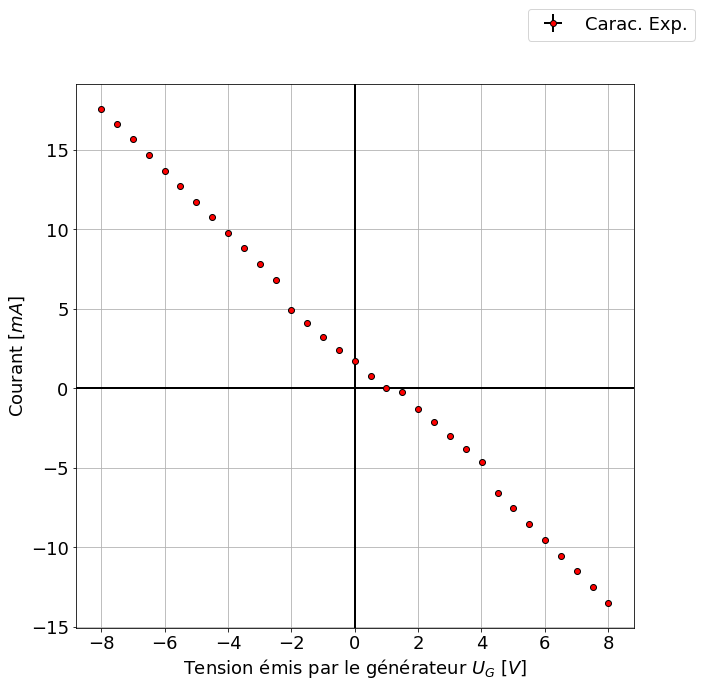

In [3]:
def I_fit(U, G = 0) : 
    return - G*U



fig = plt.figure(figsize=(10,10))
ax = fig.subplots()

Ug = data['UR [V]'] + data['Um [V]'] + data['Up [V]']
Ug = data['Ug [V]']

P = np.poly1d(np.polyfit(data['UR [V]'], -data['I [mA]'], deg = 1))
fit = curve_fit(I_fit, data['UR [V]'], -data['I [mA]'])
print(fit)

ax.errorbar(Ug, -data['I [mA]'], xerr = data['dUg [V]'], yerr = data['dI [mA]'], color = 'red', marker = 'o', markeredgecolor = 'black', ecolor='black', elinewidth = 2, ls = 'none', label = 'Carac. Exp.')
ax.errorbar(data['UR [V]']+1.1, -data['I [mA]'], color = 'blue', xerr = data['dUR [V]'], yerr = data['dI [mA]'], marker = 'o', markeredgecolor = 'black', ecolor='black', elinewidth = 2, ls = 'none', label = 'Carac. Mod. Thévenin')
#ax.plot(data['UR [V]']+1.1, P(data['UR [V]']), label = 'Linear Regression', color = 'blue')
ax.plot(data['UR [V]']+1.1, I_fit(data['UR [V]'], G=fit[0]), label = 'Linear Regression', color = 'blue')

ax.axhline(y= 0, color = 'black')
ax.axvline(x = 0, color = 'black')

ax.set_xlabel("Tension émis par le générateur $U_G$ [$V$]")
ax.set_ylabel("Courant [$mA$]")

ax.grid()

fig.legend()

fig.savefig("Graph01.pdf", dpi = _dpi)

print(P)

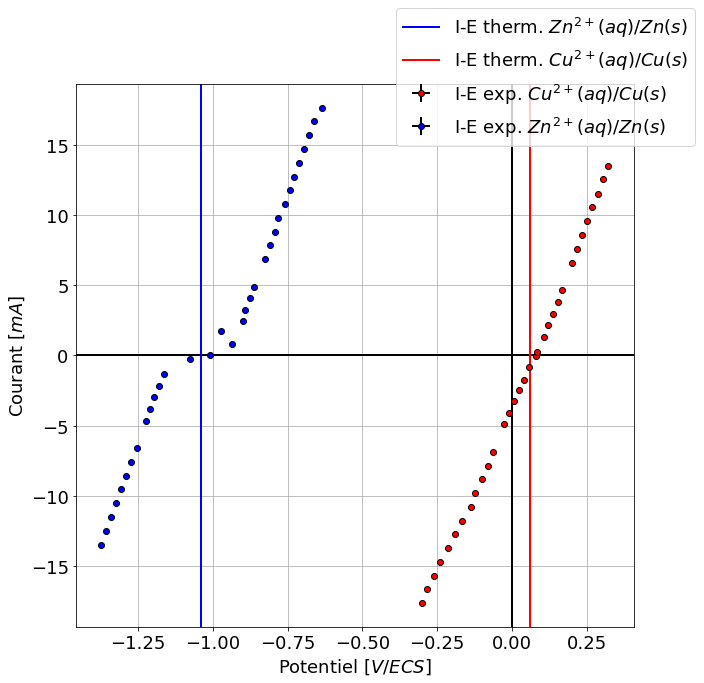

In [155]:
fig = plt.figure(figsize=(10,10))
ax = fig.subplots()

ax.errorbar(data['Up [V]'], data['I [mA]'], xerr = data['dUp [V]'], yerr = data['dI [mA]'], color = 'red', marker = 'o', markeredgecolor = 'black', ecolor='black', elinewidth = 2, ls = 'none', label = "I-E exp. $Cu^{2+} (aq) / Cu(s)$")
ax.errorbar(-data['Um [V]'], -data['I [mA]'], xerr = data['dUm [V]'], yerr = data['dI [mA]'], color = 'blue', marker = 'o', markeredgecolor = 'black', ecolor='black', elinewidth = 2, ls = 'none', label = "I-E exp. $Zn^{2+} (aq) / Zn (s)$")

ax.axhline(y= 0, color = 'black')
ax.axvline(x = 0, color = 'black')

ax.axvline(x=-1.04, color = 'blue', label = 'I-E therm. $Zn^{2+} (aq) / Zn (s)$')
ax.axvline(x=0.06, color = 'red', label = 'I-E therm. $Cu^{2+} (aq) / Cu(s)$')

ax.set_xlabel("Potentiel [$V/ECS$]")
ax.set_ylabel("Courant [$mA$]")

ax.grid()

fig.legend()

fig.savefig("Graph02.pdf", dpi = _dpi)